In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels
import datetime
from linearmodels.panel import PanelOLS

### Build dataset

In [45]:
CDS_data = pd.read_csv('data/processed/CDS/Weekly_CDS.csv')
CDS_data['Date'] = pd.to_datetime(CDS_data['Date'])
CDS_data.set_index('Date', inplace=True)

Oil_data = pd.read_csv('data/processed/Oil/oil_prices_datastream.csv')
Oil_data['Date'] = pd.to_datetime(Oil_data['Date'])
Oil_data.set_index('Date', inplace=True)

Macro_risk_variables = pd.read_csv('data/processed/Macroeconomic_variables/macro_risk_variables.csv')
Macro_risk_variables['Date'] = pd.to_datetime(Macro_risk_variables['Date'])
Macro_risk_variables.set_index('Date', inplace=True)

VIX = pd.read_csv('data/processed/Macroeconomic_variables/VIXCLS.csv')
VIX['Date'] = pd.to_datetime(VIX['Date'])
VIX.set_index('Date', inplace=True)

OVX = pd.read_csv('data/processed/Macroeconomic_variables/OVXCLS.csv')
OVX['Date'] = pd.to_datetime(OVX['Date'])
OVX.set_index('Date', inplace=True)

# =============================================================================
# MERGE (WIDE FORMAT)
# =============================================================================

merged = CDS_data.copy()
merged = pd.merge(merged, Oil_data, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, Macro_risk_variables, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, VIX, left_index=True, right_index=True, how='inner')
merged = pd.merge(merged, OVX, left_index=True, right_index=True, how='inner')

# Filter date range
merged = merged[merged.index >= datetime.datetime(2014, 1, 1)].copy()
merged.reset_index(inplace=True)

C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\4209925211.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Oil_data['Date'] = pd.to_datetime(Oil_data['Date'])
C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\4209925211.py:10: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  Macro_risk_variables['Date'] = pd.to_datetime(Macro_risk_variables['Date'])


## Setting up the regression

### Reshaping data to panel data format

In [51]:
# Oil returns (percent change)
merged['Oil_ret'] = merged['Brent'].pct_change()

# OVX change (percent change - it's a volatility index)
merged['OVX_chg'] = merged['OVXCLS'].pct_change()

# VIX change (percent change)
merged['VIX_chg'] = merged['VIXCLS'].pct_change()

# DXY change (percent change)
merged['DXY_chg'] = merged['DXY'].pct_change()

# Treasury change (diff change)
merged['UST2Y_chg'] = merged['UST2Y'].diff()
merged['UST5Y_chg'] = merged['UST5Y'].diff()
merged['UST10Y_chg'] = merged['UST10Y'].diff()


# Drop NA values from merged
#merged = merged.dropna().reset_index(drop=True)

# Check dimensions and range

print(f"\nMerged shape: {merged.shape}")
print(f"Date range: {merged['Date'].min()} to {merged['Date'].max()}")


# =============================================================================
# RESHAPE TO LONG FORMAT
# =============================================================================

oil_exporters = ['Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia', 
                 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
controls = ['Indonesia', 'Philippines', 'Turkey', 'Chile', 'China', 
            'South Africa', 'South Korea', 'Thailand']


global_vars = ['Date', 'Brent', 'Oil_ret', 'OVXCLS', 'OVX_chg', 
               'VIXCLS', 'VIX_chg', 'DXY_chg', 'UST2Y_chg', 'UST5Y_chg', 'UST10Y_chg']

merged = merged.reset_index()

panel_data = []

for country in oil_exporters + controls:
    if country not in merged.columns:
        print(f"Warning: {country} not in CDS data")
        continue
        
    temp = merged[global_vars + [country]].copy()
    temp['Country'] = country
    temp['CDS'] = temp[country]
    temp['OilExporter'] = 1 if country in oil_exporters else 0
    temp = temp.drop(columns=[country])
    panel_data.append(temp)

panel = pd.concat(panel_data, ignore_index=True)
panel = panel.sort_values(by=['Country', 'Date']).reset_index(drop=True)

# =============================================================================
# COMPUTE COUNTRY-SPECIFIC VARIABLES (CDS returns)
# =============================================================================

# CDS returns - THIS one needs groupby because it's country-specific
panel['CDS_ret'] = panel.groupby('Country')['CDS'].pct_change()

# Create interaction term
panel['OVX_x_Exporter'] = panel['OVX_chg'] * panel['OilExporter']
panel['Brent_chg_x_Exporter'] = panel['Oil_ret'] * panel['OilExporter']

# Drop NaN (first observation per country)
panel = panel.dropna(subset=['CDS_ret', 'OVX_chg', 'VIX_chg', 'DXY_chg', 'UST2Y_chg', 'UST5Y_chg', 'UST10Y_chg']).reset_index(drop=True)

panel.head()


Merged shape: (574, 92)
Date range: 2014-01-03 00:00:00 to 2024-12-27 00:00:00


,Date,Brent,Oil_ret,OVXCLS,OVX_chg,VIXCLS,VIX_chg,DXY_chg,UST2Y_chg,UST5Y_chg,UST10Y_chg,Country,CDS,OilExporter,CDS_ret,OVX_x_Exporter,Brent_chg_x_Exporter
0,2014-01-10,106.33,-0.006911,19.47,-0.054854,12.14,-0.117733,-0.001609,-0.018,-0.103,-0.135,Abu Dhabi,55.85999,1,-0.008168,-0.054854,-0.006911
1,2014-01-17,106.89,0.005267,17.12,-0.120699,12.44,0.024712,0.007067,0.001,0.005,-0.033,Abu Dhabi,55.32999,1,-0.009488,-0.120699,0.005267
2,2014-01-24,107.45,0.005239,19.46,0.136682,18.14,0.458199,-0.009479,-0.031,-0.064,-0.092,Abu Dhabi,55.34999,1,0.000361,0.136682,0.005239
3,2014-01-31,107.13,-0.002978,20.35,0.045735,18.41,0.014884,0.010564,-0.008,-0.056,-0.069,Abu Dhabi,56.32999,1,0.017706,0.045735,-0.002978
4,2014-02-07,108.21,0.010081,19.03,-0.064865,15.29,-0.169473,-0.007625,-0.033,-0.048,0.009,Abu Dhabi,56.32999,1,0.000000,-0.064865,0.010081


## Panel regressions

In [52]:
print("\n" + "="*70)
print("MODEL 1: Oil  +  Controls only")
print("="*70)

X1 = sm.add_constant(panel[['VIX_chg','OVX_chg']])
model1 = sm.OLS(panel['CDS_ret'], X1).fit(cov_type='cluster', cov_kwds={'groups': panel['Country']})
print(model1.summary())



MODEL 1: Oil  +  Controls only
                            OLS Regression Results                            
Dep. Variable:                CDS_ret   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     139.7
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           7.41e-11
Time:                        10:15:42   Log-Likelihood:                 11398.
No. Observations:                9129   AIC:                        -2.279e+04
Df Residuals:                    9126   BIC:                        -2.277e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.000

In [53]:
print("\n" + "="*70)
print("MODEL 2: Oil  +  Dummy")
print("="*70)

X1 = sm.add_constant(panel[['OVX_chg','OVX_x_Exporter', 'VIX_chg']])
model1 = sm.OLS(panel['CDS_ret'], X1).fit(cov_type='cluster', cov_kwds={'groups': panel['Country']})
print(model1.summary())



MODEL 2: Oil  +  Dummy
                            OLS Regression Results                            
Dep. Variable:                CDS_ret   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     110.4
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           6.65e-11
Time:                        10:16:01   Log-Likelihood:                 11401.
No. Observations:                9129   AIC:                        -2.279e+04
Df Residuals:                    9125   BIC:                        -2.276e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0

## Quantile regressions

In [19]:
print("="*70)
print("DESIGN 1: EXTREME OIL MOVES ONLY (top/bottom 10%)")
print("="*70)

# Define extreme oil moves

for pct in [0.10, 0.05, 0.01, 0.005]:


    oil_qtl = panel['OVX_chg'].quantile(1-pct)

    extreme_panel = panel[(panel['OVX_chg'] > oil_qtl)]

    print(f"Extreme observations: {len(extreme_panel)} ({len(extreme_panel)/len(panel)*100:.1f}%)")

    X = sm.add_constant(extreme_panel[['OVX_chg', 'VIX_chg', 'OVX x OilExporter']])
    model = sm.OLS(extreme_panel['CDS_ret'], X).fit(cov_type='cluster', cov_kwds={'groups': extreme_panel['Country']})
    print(model.summary())

DESIGN 1: EXTREME OIL MOVES ONLY (top/bottom 10%)
Extreme observations: 901 (9.9%)
                            OLS Regression Results                            
Dep. Variable:                CDS_ret   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.293
Method:                 Least Squares   F-statistic:                     69.48
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           2.15e-09
Time:                        09:40:37   Log-Likelihood:                 672.49
No. Observations:                 901   AIC:                            -1337.
Df Residuals:                     897   BIC:                            -1318.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [20]:
print("="*70)
print("DESIGN 1: EXTREME OIL MOVES WITH FIXED EFFECTS")
print("="*70)

for pct in [0.10, 0.05, 0.01, 0.005]:
    
    oil_qtl = panel['OVX_chg'].quantile(1-pct)
    extreme_panel = panel[(panel['OVX_chg'] > oil_qtl)].copy()
    
    print(f"\n{'='*70}")
    print(f"Threshold: top {pct*100:.1f}% | Observations: {len(extreme_panel)}")
    print("="*70)
    
    # Set up MultiIndex for panel data (required by linearmodels)
    extreme_panel = extreme_panel.set_index(['Country', 'Date'])
    
    # Define variables
    y = extreme_panel['CDS_ret']
    X = extreme_panel[['OVX_chg', 'VIX_chg', 'OVX x OilExporter']]
    
    # Model with entity (country) and time fixed effects
    model = PanelOLS(y, X, 
                     entity_effects=True,    # Country fixed effects
                     time_effects=True,      # Time fixed effects
                     drop_absorbed=True)     # Drop collinear variables
    
    # Fit with clustered standard errors by country
    results = model.fit(cov_type='clustered', cluster_entity=True)
    
    print(results.summary)

DESIGN 1: EXTREME OIL MOVES WITH FIXED EFFECTS

Threshold: top 10.0% | Observations: 901
                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.0276
Estimator:                   PanelOLS   R-squared (Between):              0.4758
No. Observations:                 901   R-squared (Within):               0.0906
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.1536
Time:                        09:40:38   Log-likelihood                    1061.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      23.594
Entities:                          17   P-value                           0.0000
Avg Obs:                       53.000   Distribution:                   F(1,831)
Min Obs:                       53.000                                           
Max Obs:            

C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\2712893223.py:28: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

OVX_chg, VIX_chg

  results = model.fit(cov_type='clustered', cluster_entity=True)
C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\2712893223.py:28: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

OVX_chg, VIX_chg

  results = model.fit(cov_type='clustered', cluster_entity=True)
C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\2712893223.py:28: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

OVX_chg, VIX_chg

  results = model.fit(cov_type='clustered', cluster_entity=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.0486
Estimator:                   PanelOLS   R-squared (Between):              0.3849
No. Observations:                  85   R-squared (Within):               0.0773
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.2100
Time:                        09:40:38   Log-likelihood                    52.580
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.2183
Entities:                          17   P-value                           0.0776
Avg Obs:                       5.0000   Distribution:                    F(1,63)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             2.9267
                            

C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_38992\2712893223.py:28: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

VIX_chg

  results = model.fit(cov_type='clustered', cluster_entity=True)


## Core panel regression

In [54]:
# Create a copy for regression
reg_panel = panel.copy()

# Set MultiIndex (required by linearmodels)
reg_panel['Date'] = pd.to_datetime(reg_panel['Date'])
reg_panel = reg_panel.set_index(['Country', 'Date'])

# Define dependent variable
y = reg_panel['CDS_ret']

#### Model 1: Baseline with no fixed effects

In [55]:
print("="*70)
print("MODEL 1: BASELINE (No Fixed Effects)")
print("="*70)

X_1 = reg_panel[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg']]

model_1 = PanelOLS(y, X_1, 
                   entity_effects=False, 
                   time_effects=False)

results_1 = model_1.fit(cov_type='clustered', cluster_entity=True)
print(results_1.summary)

MODEL 1: BASELINE (No Fixed Effects)
                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.2117
Estimator:                   PanelOLS   R-squared (Between):              0.6177
No. Observations:                9129   R-squared (Within):               0.2112
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.2117
Time:                        10:16:11   Log-likelihood                  1.14e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      816.90
Entities:                          17   P-value                           0.0000
Avg Obs:                       537.00   Distribution:                  F(3,9126)
Min Obs:                       537.00                                           
Max Obs:                       537.00   F-statistic (robust):           

#### Model 2: Baseline + global controls with no fixed effects

In [56]:
# =============================================================================
# MODEL 2: BASELINE + GLOBAL CONTROLS (No Fixed Effects)
# =============================================================================

print("\n" + "="*70)
print("MODEL 2: BASELINE + GLOBAL CONTROLS (No Fixed Effects)")
print("="*70)

X_2 = reg_panel[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg', 'UST5Y_chg', 'UST2Y_chg']]

model_2 = PanelOLS(y, X_2, 
                   entity_effects=False, 
                   time_effects=False)

results_2 = model_2.fit(cov_type='clustered', cluster_entity=True)
print(results_2.summary)


MODEL 2: BASELINE + GLOBAL CONTROLS (No Fixed Effects)
                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.2641
Estimator:                   PanelOLS   R-squared (Between):              0.5082
No. Observations:                9129   R-squared (Within):               0.2638
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.2641
Time:                        10:16:16   Log-likelihood                 1.171e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      467.64
Entities:                          17   P-value                           0.0000
Avg Obs:                       537.00   Distribution:                  F(7,9122)
Min Obs:                       537.00                                           
Max Obs:                       537.00   F-statistic (

#### Model 3: Country fixed effects + global controls

In [57]:
print("\n" + "="*70)
print("MODEL 3: COUNTRY FE + GLOBAL CONTROLS")
print("="*70)

X_3 = reg_panel[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg', 'UST5Y_chg', 'UST2Y_chg']]

model_3 = PanelOLS(y, X_3, 
                   entity_effects=True,    # Country FE
                   time_effects=False)

results_3 = model_3.fit(cov_type='clustered', cluster_entity=True)
print(results_3.summary)


MODEL 3: COUNTRY FE + GLOBAL CONTROLS
                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.2638
Estimator:                   PanelOLS   R-squared (Between):              0.4994
No. Observations:                9129   R-squared (Within):               0.2638
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.2641
Time:                        10:16:23   Log-likelihood                 1.172e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      466.14
Entities:                          17   P-value                           0.0000
Avg Obs:                       537.00   Distribution:                  F(7,9105)
Min Obs:                       537.00                                           
Max Obs:                       537.00   F-statistic (robust):         

#### Model 4: Country FE + Time FE

In [58]:
# Only interaction survives - all global vars absorbed by time FE
X_4 = reg_panel[['OVX_x_Exporter']]

model_4 = PanelOLS(y, X_4, 
                   entity_effects=True,    # Country FE
                   time_effects=True)      # Time FE

results_4 = model_4.fit(cov_type='clustered', cluster_entity=True)
print(results_4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                CDS_ret   R-squared:                        0.0011
Estimator:                   PanelOLS   R-squared (Between):              0.0814
No. Observations:                9129   R-squared (Within):               0.0171
Date:                Fri, Jan 30 2026   R-squared (Overall):              0.0172
Time:                        10:16:35   Log-likelihood                 1.466e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.8587
Entities:                          17   P-value                           0.0017
Avg Obs:                       537.00   Distribution:                  F(1,8575)
Min Obs:                       537.00                                           
Max Obs:                       537.00   F-statistic (robust):             0.8840
                            

In [61]:
print("\n" + "="*70)
print("COMPARISON TABLE: OVX × OilExporter Coefficient")
print("="*70)

print(f"\n{'Model':<45} {'β':>10} {'SE':>10} {'p-value':>10} {'R²':>10}")
print("-"*85)

models = [
    ('Model 1: Baseline', results_1),
    ('Model 2: + Global Controls', results_2),
    ('Model 3: + Country FE', results_3),
    ('Model 4: + Country FE + Time FE', results_4),
]

for name, res in models:
    beta = res.params['OVX_x_Exporter']
    se = res.std_errors['OVX_x_Exporter']
    pval = res.pvalues['OVX_x_Exporter']
    r2 = res.rsquared_within if hasattr(res, 'rsquared_within') else res.rsquared
    
    sig = ''
    if pval < 0.1: sig = '*'
    if pval < 0.05: sig = '**'
    if pval < 0.01: sig = '***'
    
    print(f"{name:<45} {beta:>10.4f} {se:>10.4f} {pval:>10.4f} {r2:>10.4f} {sig}")

print("\n* p<0.1, ** p<0.05, *** p<0.01")
print("Standard errors clustered by country")


COMPARISON TABLE: OVX × OilExporter Coefficient

Model                                                  β         SE    p-value         R²
-------------------------------------------------------------------------------------
Model 1: Baseline                                 0.0254     0.0262     0.3323     0.2112 
Model 2: + Global Controls                        0.0254     0.0262     0.3324     0.2638 
Model 3: + Country FE                             0.0253     0.0261     0.3322     0.2638 
Model 4: + Country FE + Time FE                   0.0253     0.0270     0.3471     0.0171 

* p<0.1, ** p<0.05, *** p<0.01
Standard errors clustered by country


### Quantile regressions for panel

In [65]:
# =============================================================================
# THRESHOLD ANALYSIS: EXTREME OVX MOVES WITH FIXED EFFECTS
# =============================================================================

print("\n" + "="*70)
print("THRESHOLD ANALYSIS: EXTREME OVX MOVES")
print("="*70)

results_list = []

for pct in [1.0, 0.10, 0.05, 0.01]:
    
    if pct == 1.0:
        # Full sample
        extreme = panel.copy()
        threshold_label = 'Full Sample'
    else:
        # Filter to extreme OVX moves (top pct%)
        oil_qtl = panel['OVX_chg'].quantile(1 - pct)
        extreme = panel[panel['OVX_chg'] > oil_qtl].copy()
        threshold_label = f'Top {pct*100:.1f}%'
    
    # Prepare for linearmodels
    extreme['Date'] = pd.to_datetime(extreme['Date'])
    extreme = extreme.set_index(['Country', 'Date'])
    
    y = extreme['CDS_ret']
    
    # Model A: Country FE + explicit global controls
    X_a = extreme[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
    model_a = PanelOLS(y, X_a, entity_effects=True, time_effects=False, drop_absorbed=True, check_rank=False)
    res_a = model_a.fit(cov_type='clustered', cluster_entity=True)
    
    # Model B: Country FE + Time FE
    X_b = extreme[['OVX_x_Exporter']]
    model_b = PanelOLS(y, X_b, entity_effects=True, time_effects=True, drop_absorbed=True)
    res_b = model_b.fit(cov_type='clustered', cluster_entity=True)
    
    results_list.append({
        'Threshold': threshold_label,
        'N': len(y),
        'β_A': res_a.params['OVX_x_Exporter'],
        'SE_A': res_a.std_errors['OVX_x_Exporter'],
        'p_A': res_a.pvalues['OVX_x_Exporter'],
        'β_B': res_b.params['OVX_x_Exporter'],
        'SE_B': res_b.std_errors['OVX_x_Exporter'],
        'p_B': res_b.pvalues['OVX_x_Exporter'],
    })

# Print results
print(f"\n{'Threshold':<15} {'N':>6} │ {'β (A)':>8} {'SE':>8} {'p':>8} │ {'β (B)':>8} {'SE':>8} {'p':>8}")
print("-"*85)

for row in results_list:
    sig_a = '***' if row['p_A'] < 0.01 else '**' if row['p_A'] < 0.05 else '*' if row['p_A'] < 0.1 else ''
    sig_b = '***' if row['p_B'] < 0.01 else '**' if row['p_B'] < 0.05 else '*' if row['p_B'] < 0.1 else ''
    
    print(f"{row['Threshold']:<15} {row['N']:>6} │ "
          f"{row['β_A']:>8.4f} {row['SE_A']:>8.4f} {row['p_A']:>7.3f}{sig_a:<3} │ "
          f"{row['β_B']:>8.4f} {row['SE_B']:>8.4f} {row['p_B']:>7.3f}{sig_b:<3}")

print("\nModel A: Country FE + Global controls")
print("Model B: Country FE + Time FE")
print("* p<0.1, ** p<0.05, *** p<0.01 | Clustered SEs by country")


THRESHOLD ANALYSIS: EXTREME OVX MOVES

Threshold            N │    β (A)       SE        p │    β (B)       SE        p
-------------------------------------------------------------------------------------
Full Sample       9129 │   0.0253   0.0261   0.332    │   0.0253   0.0270   0.347   
Top 10.0%          901 │   0.1412   0.0438   0.001*** │   0.1412   0.0455   0.002***
Top 5.0%           442 │   0.1473   0.0660   0.026**  │   0.1473   0.0690   0.034** 
Top 1.0%            85 │   0.6082   0.3155   0.058*   │   0.6082   0.3555   0.092*  

Model A: Country FE + Global controls
Model B: Country FE + Time FE
* p<0.1, ** p<0.05, *** p<0.01 | Clustered SEs by country


#### Robustness: What if we randomize oil exporters and controls

PERMUTATION TEST: Random Country Groupings
Total countries: 17
Exporters in each permutation: 9
Number of permutations: 1000

Running permutations...
  Permutation 100/1000
  Permutation 200/1000
  Permutation 300/1000
  Permutation 400/1000
  Permutation 500/1000
  Permutation 600/1000
  Permutation 700/1000
  Permutation 800/1000
  Permutation 900/1000
  Permutation 1000/1000
Done!

PERMUTATION TEST RESULTS

Sample              True β    Perm Mean    Perm SD   Percentile    p-value
----------------------------------------------------------------------
Full Sample         0.0253      -0.0002     0.0276        82.2%      0.178 
Top 10%             0.1412       0.0020     0.0564        99.6%      0.004 ***
Top 5%              0.1473       0.0018     0.0772        97.1%      0.029 **
Top 1%              0.6082       0.0106     0.3510        95.2%      0.048 **

* p<0.1, ** p<0.05, *** p<0.01
p-value = proportion of random groupings with β ≥ true β
Percentile = % of random groupings with 

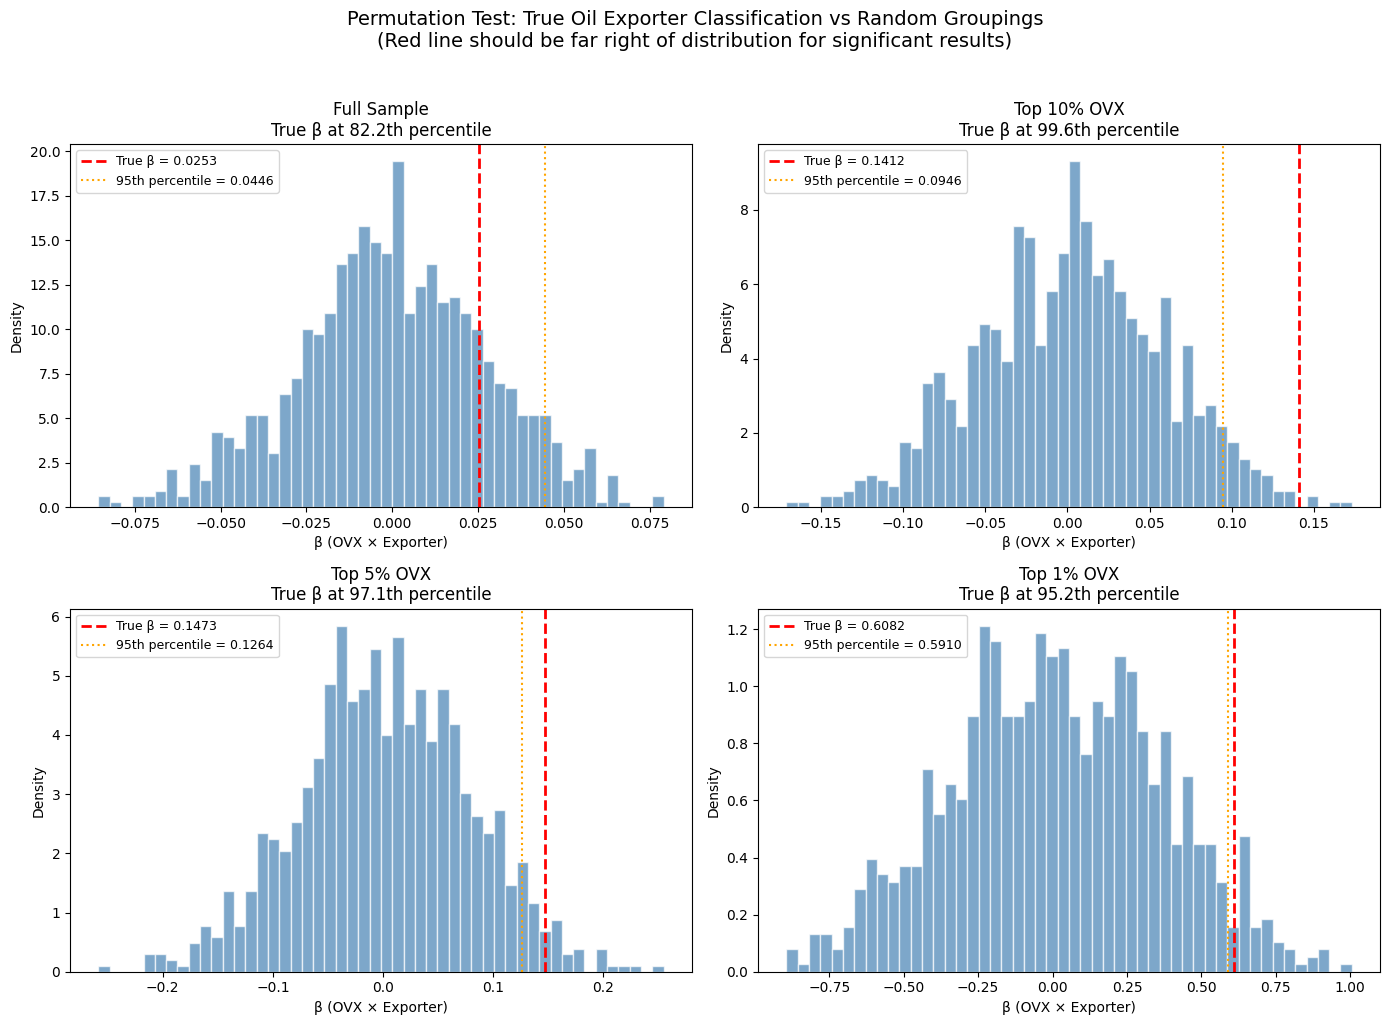


Figure saved: permutation_test_results.png


In [63]:
import numpy as np
from linearmodels.panel import PanelOLS
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# PERMUTATION TEST: DOES OIL EXPORTER CLASSIFICATION MATTER?
# =============================================================================

np.random.seed(42)  # For reproducibility

# All countries
all_countries = oil_exporters + controls
n_exporters = len(oil_exporters)
n_total = len(all_countries)

# Number of permutations
n_permutations = 1000

# Store results
permuted_betas = []
permuted_betas_10pct = []
permuted_betas_5pct = []
permuted_betas_1pct = []

print("="*70)
print("PERMUTATION TEST: Random Country Groupings")
print("="*70)
print(f"Total countries: {n_total}")
print(f"Exporters in each permutation: {n_exporters}")
print(f"Number of permutations: {n_permutations}")
print("\nRunning permutations...")

for i in range(n_permutations):
    
    if (i + 1) % 100 == 0:
        print(f"  Permutation {i + 1}/{n_permutations}")
    
    # Randomly assign countries to "exporter" group
    random_exporters = np.random.choice(all_countries, size=n_exporters, replace=False)
    
    # Create permuted panel
    perm_panel = panel.copy()
    perm_panel['OilExporter_perm'] = perm_panel['Country'].isin(random_exporters).astype(int)
    perm_panel['OVX_x_Exporter_perm'] = perm_panel['OVX_chg'] * perm_panel['OilExporter_perm']
    
    # Prepare for regression
    perm_panel['Date'] = pd.to_datetime(perm_panel['Date'])
    perm_reg = perm_panel.set_index(['Country', 'Date'])
    
    # --- FULL SAMPLE ---
    try:
        y = perm_reg['CDS_ret']
        X = perm_reg[['OVX_chg', 'OVX_x_Exporter_perm', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
        model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
        results = model.fit(cov_type='clustered', cluster_entity=True)
        permuted_betas.append(results.params['OVX_x_Exporter_perm'])
    except:
        permuted_betas.append(np.nan)
    
    # --- TOP 10% ---
    try:
        oil_qtl_10 = perm_panel['OVX_chg'].quantile(0.90)
        extreme_10 = perm_panel[perm_panel['OVX_chg'] > oil_qtl_10].copy()
        extreme_10 = extreme_10.set_index(['Country', 'Date'])
        
        y = extreme_10['CDS_ret']
        X = extreme_10[['OVX_chg', 'OVX_x_Exporter_perm', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
        model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
        results = model.fit(cov_type='clustered', cluster_entity=True)
        permuted_betas_10pct.append(results.params['OVX_x_Exporter_perm'])
    except:
        permuted_betas_10pct.append(np.nan)
    
    # --- TOP 5% ---
    try:
        oil_qtl_5 = perm_panel['OVX_chg'].quantile(0.95)
        extreme_5 = perm_panel[perm_panel['OVX_chg'] > oil_qtl_5].copy()
        extreme_5 = extreme_5.set_index(['Country', 'Date'])
        
        y = extreme_5['CDS_ret']
        X = extreme_5[['OVX_chg', 'OVX_x_Exporter_perm', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
        model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
        results = model.fit(cov_type='clustered', cluster_entity=True)
        permuted_betas_5pct.append(results.params['OVX_x_Exporter_perm'])
    except:
        permuted_betas_5pct.append(np.nan)
    
    # --- TOP 1% ---
    try:
        oil_qtl_1 = perm_panel['OVX_chg'].quantile(0.99)
        extreme_1 = perm_panel[perm_panel['OVX_chg'] > oil_qtl_1].copy()
        extreme_1 = extreme_1.set_index(['Country', 'Date'])
        
        y = extreme_1['CDS_ret']
        X = extreme_1[['OVX_chg', 'OVX_x_Exporter_perm', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
        model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
        results = model.fit(cov_type='clustered', cluster_entity=True)
        permuted_betas_1pct.append(results.params['OVX_x_Exporter_perm'])
    except:
        permuted_betas_1pct.append(np.nan)

print("Done!")

# =============================================================================
# GET TRUE BETAS (from actual oil exporter classification)
# =============================================================================

reg_panel = panel.copy()
reg_panel['Date'] = pd.to_datetime(reg_panel['Date'])
reg_panel = reg_panel.set_index(['Country', 'Date'])

# Full sample
y = reg_panel['CDS_ret']
X = reg_panel[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
results = model.fit(cov_type='clustered', cluster_entity=True)
true_beta_full = results.params['OVX_x_Exporter']

# Top 10%
extreme = panel[panel['OVX_chg'] > panel['OVX_chg'].quantile(0.90)].copy()
extreme['Date'] = pd.to_datetime(extreme['Date'])
extreme = extreme.set_index(['Country', 'Date'])
y = extreme['CDS_ret']
X = extreme[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
results = model.fit(cov_type='clustered', cluster_entity=True)
true_beta_10pct = results.params['OVX_x_Exporter']

# Top 5%
extreme = panel[panel['OVX_chg'] > panel['OVX_chg'].quantile(0.95)].copy()
extreme['Date'] = pd.to_datetime(extreme['Date'])
extreme = extreme.set_index(['Country', 'Date'])
y = extreme['CDS_ret']
X = extreme[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
results = model.fit(cov_type='clustered', cluster_entity=True)
true_beta_5pct = results.params['OVX_x_Exporter']

# Top 1%
extreme = panel[panel['OVX_chg'] > panel['OVX_chg'].quantile(0.99)].copy()
extreme['Date'] = pd.to_datetime(extreme['Date'])
extreme = extreme.set_index(['Country', 'Date'])
y = extreme['CDS_ret']
X = extreme[['OVX_chg', 'OVX_x_Exporter', 'VIX_chg', 'DXY_chg', 'UST10Y_chg']]
model = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
results = model.fit(cov_type='clustered', cluster_entity=True)
true_beta_1pct = results.params['OVX_x_Exporter']

# =============================================================================
# COMPUTE PERMUTATION P-VALUES
# =============================================================================

# Clean NaN values
permuted_betas = [b for b in permuted_betas if not np.isnan(b)]
permuted_betas_10pct = [b for b in permuted_betas_10pct if not np.isnan(b)]
permuted_betas_5pct = [b for b in permuted_betas_5pct if not np.isnan(b)]
permuted_betas_1pct = [b for b in permuted_betas_1pct if not np.isnan(b)]

# Calculate percentile of true beta in permuted distribution
perm_pval_full = np.mean([b >= true_beta_full for b in permuted_betas])
perm_pval_10pct = np.mean([b >= true_beta_10pct for b in permuted_betas_10pct])
perm_pval_5pct = np.mean([b >= true_beta_5pct for b in permuted_betas_5pct])
perm_pval_1pct = np.mean([b >= true_beta_1pct for b in permuted_betas_1pct])

# Percentile rank (what % of random betas is the true beta larger than?)
percentile_full = np.mean([b < true_beta_full for b in permuted_betas]) * 100
percentile_10pct = np.mean([b < true_beta_10pct for b in permuted_betas_10pct]) * 100
percentile_5pct = np.mean([b < true_beta_5pct for b in permuted_betas_5pct]) * 100
percentile_1pct = np.mean([b < true_beta_1pct for b in permuted_betas_1pct]) * 100

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n" + "="*70)
print("PERMUTATION TEST RESULTS")
print("="*70)

print(f"\n{'Sample':<15} {'True β':>10} {'Perm Mean':>12} {'Perm SD':>10} {'Percentile':>12} {'p-value':>10}")
print("-"*70)

results_table = [
    ('Full Sample', true_beta_full, permuted_betas, percentile_full, perm_pval_full),
    ('Top 10%', true_beta_10pct, permuted_betas_10pct, percentile_10pct, perm_pval_10pct),
    ('Top 5%', true_beta_5pct, permuted_betas_5pct, percentile_5pct, perm_pval_5pct),
    ('Top 1%', true_beta_1pct, permuted_betas_1pct, percentile_1pct, perm_pval_1pct),
]

for name, true_b, perm_b, pctile, pval in results_table:
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    print(f"{name:<15} {true_b:>10.4f} {np.mean(perm_b):>12.4f} {np.std(perm_b):>10.4f} "
          f"{pctile:>11.1f}% {pval:>10.3f} {sig}")

print("\n* p<0.1, ** p<0.05, *** p<0.01")
print("p-value = proportion of random groupings with β ≥ true β")
print("Percentile = % of random groupings with β < true β")

# =============================================================================
# PLOT DISTRIBUTIONS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_data = [
    ('Full Sample', permuted_betas, true_beta_full, percentile_full),
    ('Top 10% OVX', permuted_betas_10pct, true_beta_10pct, percentile_10pct),
    ('Top 5% OVX', permuted_betas_5pct, true_beta_5pct, percentile_5pct),
    ('Top 1% OVX', permuted_betas_1pct, true_beta_1pct, percentile_1pct),
]

for ax, (title, perm_b, true_b, pctile) in zip(axes.flatten(), plot_data):
    ax.hist(perm_b, bins=50, alpha=0.7, color='steelblue', edgecolor='white', density=True)
    ax.axvline(true_b, color='red', linewidth=2, linestyle='--', label=f'True β = {true_b:.4f}')
    ax.axvline(np.percentile(perm_b, 95), color='orange', linewidth=1.5, linestyle=':', 
               label=f'95th percentile = {np.percentile(perm_b, 95):.4f}')
    
    ax.set_title(f'{title}\nTrue β at {pctile:.1f}th percentile', fontsize=12)
    ax.set_xlabel('β (OVX × Exporter)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Permutation Test: True Oil Exporter Classification vs Random Groupings\n'
             '(Red line should be far right of distribution for significant results)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('permutation_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: permutation_test_results.png")